# 🍎 Reentrenamiento y Evaluación: EfficientNet-B0 — Fruits-360

Este notebook **reentrena desde cero** un clasificador de frutas usando EfficientNet-B0 con el dataset `PedroSampaio/fruits-360`, y luego lo evalúa sobre el split `test`.

| Parámetro | Valor |
|---|---|
| **Arquitectura** | EfficientNet-B0 (backbone ImageNet + fine-tuning completo) |
| **Dataset** | `PedroSampaio/fruits-360` (train: ~67k imgs, test: ~22k imgs) |
| **Clases** | 113 originales → fusionadas a 76 (igual que el modelo original) |
| **Estrategia** | Phase 1: entrenar solo cabeza (5 épocas) → Phase 2: fine-tuning completo (10 épocas) |
| **Dispositivo** | CUDA (recomendado) / CPU |

> ⚠️ **Requiere GPU.** En Google Colab: `Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU (T4)`.

## 1. Instalación de dependencias

In [1]:
!pip install torch torchvision huggingface_hub datasets Pillow scikit-learn matplotlib seaborn tqdm pyarrow -q
print('✅ Dependencias instaladas.')

✅ Dependencias instaladas.


## 2. Imports y dispositivo

In [2]:
import os, re, json, copy, time
import numpy as np
import pandas as pd
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image as PILImage
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset as TorchDataset
import torchvision.models as models
from torchvision import transforms

from datasets import (
    Dataset, Features, ClassLabel,
    Image as HFImage, load_dataset_builder, load_dataset
)
from huggingface_hub import hf_hub_download
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, top_k_accuracy_score,
    f1_score, precision_score, recall_score
)
from tqdm.auto import tqdm

print(f'PyTorch     : {torch.__version__}')
print(f'CUDA        : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo : {DEVICE}')

PyTorch     : 2.10.0+cu128
CUDA        : True
GPU         : Tesla T4
Dispositivo : cuda


## 3. Configuración global

In [3]:
# ── Rutas locales (parquet subidos a Colab) ──────────────────────────────────
TRAIN_PARQUET = '/content/train.parquet'   # Opcional: si tienes el archivo local
TEST_PARQUET  = '/content/test.parquet'    # Opcional: si tienes el archivo local
HF_DATASET_ID = 'PedroSampaio/fruits-360' # Fuente HuggingFace (fallback automático)

# ── Hiperparámetros ──────────────────────────────────────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 64
NUM_WORKERS   = 2

# Phase 1: solo cabeza clasificadora
EPOCHS_HEAD   = 5
LR_HEAD       = 1e-3

# Phase 2: fine-tuning completo del backbone
EPOCHS_FULL   = 10
LR_FULL       = 1e-4
LR_BACKBONE   = 1e-5   # backbone con LR más bajo

WEIGHT_DECAY  = 1e-4
PATIENCE      = 4       # early stopping
SAVE_PATH     = '/content/best_model.pth'

# ── Seed reproducible ───────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print('Configuración lista.')

Configuración lista.


## 4. Carga del dataset

Carga desde archivo local si existe, sino descarga desde HuggingFace Hub.

In [4]:
# ── Obtener nombres de clases sin descargar el dataset completo ─────────────
print(f'Obteniendo metadatos de {HF_DATASET_ID}...')
builder = load_dataset_builder(HF_DATASET_ID)
all_class_names = builder.info.features['label'].names  # 113 clases originales
print(f'Clases en el dataset original: {len(all_class_names)}')

features_def = Features({
    'image': HFImage(),
    'label': ClassLabel(names=all_class_names)
})

def load_split_from_parquet(path, features):
    """Carga un split desde un archivo parquet local."""
    df = pd.read_parquet(path)
    ds = Dataset.from_pandas(df).cast(features)
    def open_bytes(ex):
        if isinstance(ex['image'], dict) and 'bytes' in ex['image']:
            try:
                ex['image'] = PILImage.open(BytesIO(ex['image']['bytes'])).convert('RGB')
            except Exception:
                ex['image'] = None
        return ex
    ds = ds.map(open_bytes, num_proc=1)
    ds = ds.filter(lambda x: x['image'] is not None)
    ds = ds.cast(Features({'image': HFImage(), 'label': ds.features['label']}))
    return ds

# ── Cargar train ─────────────────────────────────────────────────────────────
if os.path.exists(TRAIN_PARQUET):
    print(f'\nCargando train desde {TRAIN_PARQUET}...')
    train_hf = load_split_from_parquet(TRAIN_PARQUET, features_def)
else:
    print('\nDescargando train desde HuggingFace Hub...')
    train_hf = load_dataset(HF_DATASET_ID, split='train')

# ── Cargar test ──────────────────────────────────────────────────────────────
if os.path.exists(TEST_PARQUET):
    print(f'Cargando test desde {TEST_PARQUET}...')
    test_hf = load_split_from_parquet(TEST_PARQUET, features_def)
else:
    print('Descargando test desde HuggingFace Hub...')
    test_hf = load_dataset(HF_DATASET_ID, split='test')

all_class_names = train_hf.features['label'].names
print(f'\n✅ Train: {len(train_hf):,} muestras')
print(f'✅ Test : {len(test_hf):,} muestras')
print(f'Clases  : {len(all_class_names)}')

Obteniendo metadatos de PedroSampaio/fruits-360...


README.md: 0.00B [00:00, ?B/s]

Clases en el dataset original: 113

Descargando train desde HuggingFace Hub...


data/train-00000-of-00001-086dc013443c48(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

data/test-00000-of-00001-0d294abe3826b2e(…):   0%|          | 0.00/98.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67690 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22688 [00:00<?, ? examples/s]

Descargando test desde HuggingFace Hub...

✅ Train: 67,690 muestras
✅ Test : 22,688 muestras
Clases  : 113


## 5. Fusión de clases: 113 → 76

Replicamos la misma lógica del modelo original: fusionar variantes numéricas y de color en una clase genérica.

In [5]:
def get_base_class(name: str) -> str:
    """Extrae la clase base eliminando variantes numéricas y de color."""
    name = name.strip()
    name = re.sub(r'\s*\(.*?\)', '', name)            # quitar paréntesis
    name = re.sub(r'\s+(Red|Yellow|Green|White|Black|Pink|Golden|Crimson|Dark|Lady|\d+).*$',
                  '', name, flags=re.IGNORECASE)       # quitar descriptores de color/número
    return name.strip()

# Construir las 76 clases fusionadas en el mismo orden que el modelo original
seen = []
orig_to_fused = {}  # nombre_original -> nombre_fusionado
for name in all_class_names:
    base = get_base_class(name)
    orig_to_fused[name] = base
    if base not in seen:
        seen.append(base)

fused_classes = seen  # Lista de 76 clases fusionadas
fused_to_idx  = {c: i for i, c in enumerate(fused_classes)}

# Mapeo de índice original (0-112) → índice fusionado (0-75)
orig_idx_to_fused_idx = {
    i: fused_to_idx[orig_to_fused[name]]
    for i, name in enumerate(all_class_names)
}

NUM_CLASSES = len(fused_classes)
id2label    = {str(i): c for i, c in enumerate(fused_classes)}

print(f'Clases fusionadas: {NUM_CLASSES}')
print(f'Primeras 10: {fused_classes[:10]}')
print(f'\nEjemplos de fusión:')
examples = [(n, orig_to_fused[n]) for n in all_class_names if n != orig_to_fused[n]][:10]
for orig, fused in examples:
    print(f'  {orig:<30} → {fused}')

Clases fusionadas: 93
Primeras 10: ['Apple Braeburn', 'Apple', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Avocado ripe', 'Banana', 'Beetroot', 'Blueberry', 'Cactus fruit']

Ejemplos de fusión:
  Apple Crimson Snow             → Apple
  Apple Golden                   → Apple
  Apple Pink Lady                → Apple
  Apple Red                      → Apple
  Apple Red Delicious            → Apple
  Apple Red Yellow               → Apple
  Banana Lady Finger             → Banana
  Banana Red                     → Banana
  Cherry Wax Black               → Cherry Wax
  Cherry Wax Red                 → Cherry Wax


## 6. PyTorch Dataset con augmentación

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class FruitDataset(TorchDataset):
    """Dataset de PyTorch que envuelve un HuggingFace Dataset."""
    def __init__(self, hf_dataset, label_map, transform):
        self.data      = hf_dataset
        self.label_map = label_map   # orig_idx -> fused_idx
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ex    = self.data[idx]
        img   = ex['image'].convert('RGB')
        label = self.label_map[ex['label']]
        return self.transform(img), label


train_dataset = FruitDataset(train_hf, orig_idx_to_fused_idx, train_transform)
test_dataset  = FruitDataset(test_hf,  orig_idx_to_fused_idx, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')
print(f'Train augment : RandomCrop, Flips, ColorJitter, Rotation')
print(f'Val transform : Resize + Normalize')

Train batches : 1058
Test  batches : 355
Train augment : RandomCrop, Flips, ColorJitter, Rotation
Val transform : Resize + Normalize


## 7. Definición del modelo

EfficientNet-B0 preentrenado en ImageNet con cabeza clasificadora reemplazada.

In [7]:
def build_model(num_classes: int, freeze_backbone: bool = True):
    """Construye EfficientNet-B0 con cabeza personalizada."""
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    # Reemplazar cabeza clasificadora
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes)
    )

    if freeze_backbone:
        # Congelar todo excepto la cabeza
        for name, param in model.named_parameters():
            if 'classifier' not in name:
                param.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Parámetros entrenables: {trainable:,} / {total:,} '
          f'({"backbone congelado" if freeze_backbone else "backbone descongelado"})')
    return model


model = build_model(NUM_CLASSES, freeze_backbone=True)
model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 88.0MB/s]


Parámetros entrenables: 119,133 / 4,126,681 (backbone congelado)


## 8. Funciones de entrenamiento y evaluación

In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_true, all_probs = [], [], []
    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        out   = model(imgs)
        loss  = criterion(out, labels)
        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())
        all_probs.extend(probs)
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_true), np.array(all_probs))


def run_training(model, train_loader, test_loader, epochs, optimizer, scheduler,
                 criterion, device, phase_name, history=None):
    """Loop de entrenamiento con early stopping y guardado del mejor modelo."""
    if history is None:
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_val_acc  = 0.0
    best_weights  = copy.deepcopy(model.state_dict())
    patience_cnt  = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc, _, _, _ = eval_epoch(model, test_loader, criterion, device)

        if scheduler is not None:
            scheduler.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        elapsed = time.time() - t0
        print(f'[{phase_name}] Época {epoch:02d}/{epochs} | '
              f'Train loss: {tr_loss:.4f} acc: {tr_acc:.4f} | '
              f'Val loss: {vl_loss:.4f} acc: {vl_acc:.4f} | '
              f'{elapsed:.0f}s')

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, SAVE_PATH)
            print(f'  ✅ Nuevo mejor modelo guardado (val_acc={vl_acc:.4f})')
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f'  ⏹ Early stopping en época {epoch}.')
                break

    model.load_state_dict(best_weights)
    print(f'\n  Mejor val_acc en {phase_name}: {best_val_acc:.4f}')
    return model, history


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
print('Funciones de entrenamiento definidas.')

Funciones de entrenamiento definidas.


## 9. Phase 1: Entrenar solo la cabeza clasificadora

El backbone de EfficientNet-B0 permanece congelado. Solo se actualizan los pesos de la capa final.

In [9]:
print('=== PHASE 1: Cabeza clasificadora (backbone congelado) ===')
print(f'Épocas: {EPOCHS_HEAD} | LR: {LR_HEAD} | Batch: {BATCH_SIZE}\n')

optimizer_head = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=WEIGHT_DECAY
)
scheduler_head = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_head, mode='min', factor=0.5, patience=2
)

model, history = run_training(
    model, train_loader, test_loader,
    epochs=EPOCHS_HEAD,
    optimizer=optimizer_head,
    scheduler=scheduler_head,
    criterion=criterion,
    device=DEVICE,
    phase_name='Phase1'
)

=== PHASE 1: Cabeza clasificadora (backbone congelado) ===
Épocas: 5 | LR: 0.001 | Batch: 64



  Train:   0%|          | 0/1058 [00:00<?, ?it/s]

  Eval :   0%|          | 0/355 [00:00<?, ?it/s]

[Phase1] Época 01/5 | Train loss: 1.6936 acc: 0.7869 | Val loss: 1.2627 acc: 0.9156 | 540s
  ✅ Nuevo mejor modelo guardado (val_acc=0.9156)


  Train:   0%|          | 0/1058 [00:00<?, ?it/s]

...

  Train:   0%|          | 0/1058 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79960cc8d3a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79960cc8d3a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Eval :   0%|          | 0/355 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79960cc8d3a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
AssertionError: can only test a child process
Exception ignored in: Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79960cc8d3a0><function _MultiProcessingDataLoaderIter.__del__ at 0x79960cc8d3a0><function _MultiProcessingDataLoaderIter.__del__ at 0x79960cc8d3a0>


Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/ut

[Phase1] Época 05/5 | Train loss: 1.2292 acc: 0.9113 | Val loss: 1.1387 acc: 0.9425 | 545s

  Mejor val_acc en Phase1: 0.9468


## 10. Phase 2: Fine-tuning completo del backbone

Se descongela todo el modelo con tasas de aprendizaje diferenciadas: más baja para el backbone (ya preentrenado), más alta para la cabeza.

In [10]:
print('=== PHASE 2: Fine-tuning completo (backbone descongelado) ===')
print(f'Épocas: {EPOCHS_FULL} | LR cabeza: {LR_FULL} | LR backbone: {LR_BACKBONE}\n')

# Descongelar todo el modelo
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Parámetros entrenables: {trainable:,} / {total:,} (backbone descongelado)')

# LR diferenciado: backbone más lento
backbone_params   = [p for n, p in model.named_parameters() if 'classifier' not in n]
classifier_params = [p for n, p in model.named_parameters() if 'classifier' in n]

optimizer_full = optim.AdamW([
    {'params': backbone_params,   'lr': LR_BACKBONE},
    {'params': classifier_params, 'lr': LR_FULL}
], weight_decay=WEIGHT_DECAY)

scheduler_full = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_full, T_max=EPOCHS_FULL, eta_min=1e-6
)

model, history = run_training(
    model, train_loader, test_loader,
    epochs=EPOCHS_FULL,
    optimizer=optimizer_full,
    scheduler=scheduler_full,
    criterion=criterion,
    device=DEVICE,
    phase_name='Phase2',
    history=history
)

=== PHASE 2: Fine-tuning completo (backbone descongelado) ===
Épocas: 10 | LR cabeza: 0.0001 | LR backbone: 1e-05

Parámetros entrenables: 4,126,681 / 4,126,681 (backbone descongelado)


  Train:   0%|          | 0/1058 [00:00<?, ?it/s]

  Eval :   0%|          | 0/355 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79960cc8d3a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79960cc8d3a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

[Phase2] Época 01/10 | Train loss: 1.1122 acc: 0.9501 | Val loss: 1.0321 acc: 0.9670 | 593s
  ✅ Nuevo mejor modelo guardado (val_acc=0.9670)


...

[Phase2] Época 09/10 | Train loss: 0.8585 acc: 0.9987 | Val loss: 0.8566 acc: 0.9919 | 574s
  ✅ Nuevo mejor modelo guardado (val_acc=0.9919)


  Train:   0%|          | 0/1058 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79960cc8d3a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
          Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79960cc8d3a0> 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()^
^^^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^^^    ^^if w.is_alive():^^^
 ^^ ^  ^ ^^ ^^ ^^^

  Eval :   0%|          | 0/355 [00:00<?, ?it/s]

[Phase2] Época 10/10 | Train loss: 0.8506 acc: 0.9993 | Val loss: 0.8500 acc: 0.9924 | 589s
  ✅ Nuevo mejor modelo guardado (val_acc=0.9924)

  Mejor val_acc en Phase2: 0.9924


## 11. Curvas de entrenamiento

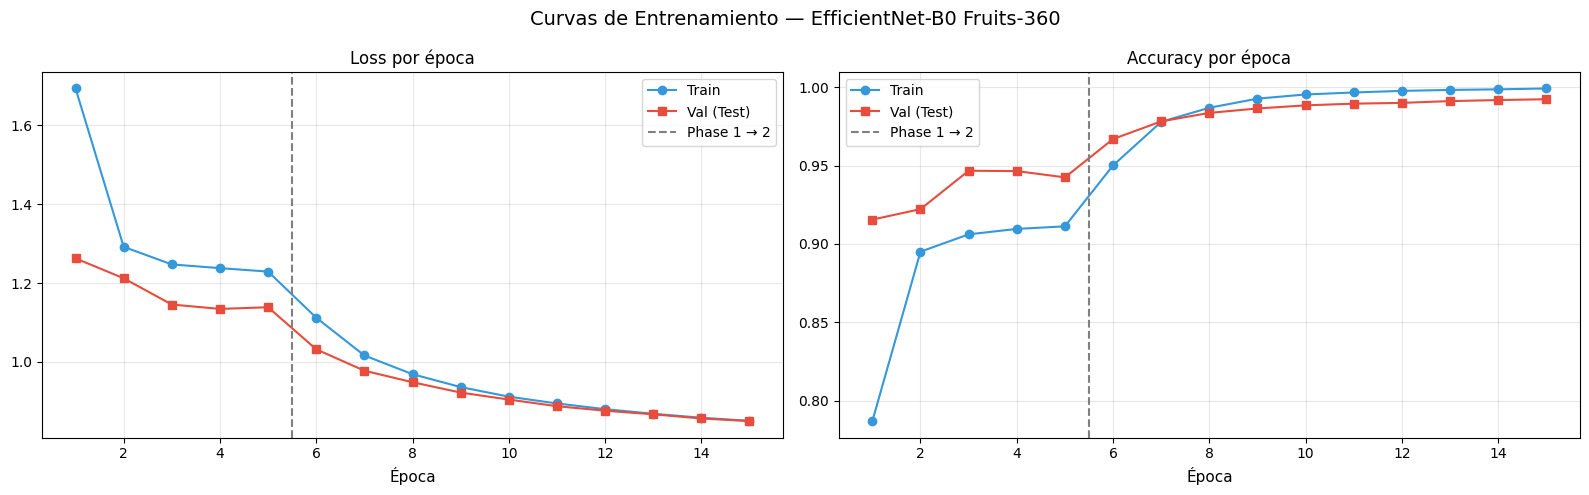

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
epochs_range = range(1, len(history['train_loss']) + 1)
phase1_end   = EPOCHS_HEAD  # línea divisoria entre phases

for ax, metric, title in zip(
    axes,
    [('train_loss', 'val_loss'), ('train_acc', 'val_acc')],
    ['Loss por época', 'Accuracy por época']
):
    train_key, val_key = metric
    ax.plot(epochs_range, history[train_key], 'o-', color='#3498db', label='Train')
    ax.plot(epochs_range, history[val_key],   's-', color='#e74c3c', label='Val (Test)')
    ax.axvline(phase1_end + 0.5, color='gray', linestyle='--', linewidth=1.5,
               label='Phase 1 → 2')
    ax.set_xlabel('Época', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — EfficientNet-B0 Fruits-360', fontsize=14)
plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Evaluación final en el test set

In [12]:
print('Ejecutando evaluación final sobre el test set...')
_, _, all_preds, all_true, all_probs = eval_epoch(
    model, test_loader, criterion, DEVICE
)

top1  = accuracy_score(all_true, all_preds)
top5  = top_k_accuracy_score(all_true, all_probs, k=5, labels=list(range(NUM_CLASSES)))
f1    = f1_score(all_true, all_preds, average='weighted', zero_division=0)
prec  = precision_score(all_true, all_preds, average='weighted', zero_division=0)
rec   = recall_score(all_true, all_preds, average='weighted', zero_division=0)
conf_ok  = all_probs.max(axis=1)[all_preds == all_true].mean()
conf_err = all_probs.max(axis=1)[all_preds != all_true].mean()

print('\n' + '=' * 58)
print('          RESULTADOS FINALES — TEST SET')
print('=' * 58)
print(f'  Modelo      : EfficientNet-B0 (fine-tuning completo)')
print(f'  Dataset     : PedroSampaio/fruits-360 (split=test)')
print(f'  Muestras    : {len(all_true):,}')
print(f'  Clases      : {NUM_CLASSES}')
print('-' * 58)
print(f'  Top-1 Accuracy    : {top1 * 100:.2f}%')
print(f'  Top-5 Accuracy    : {top5 * 100:.2f}%')
print(f'  Precision (w-avg) : {prec * 100:.2f}%')
print(f'  Recall    (w-avg) : {rec  * 100:.2f}%')
print(f'  F1-Score  (w-avg) : {f1   * 100:.2f}%')
print('-' * 58)
print(f'  Confianza media (aciertos) : {conf_ok:.4f}')
print(f'  Confianza media (errores)  : {conf_err:.4f}')
print('=' * 58)

Ejecutando evaluación final sobre el test set...


  Eval :   0%|          | 0/355 [00:00<?, ?it/s]


          RESULTADOS FINALES — TEST SET
  Modelo      : EfficientNet-B0 (fine-tuning completo)
  Dataset     : PedroSampaio/fruits-360 (split=test)
  Muestras    : 22,688
  Clases      : 93
----------------------------------------------------------
  Top-1 Accuracy    : 99.24%
  Top-5 Accuracy    : 99.93%
  Precision (w-avg) : 99.30%
  Recall    (w-avg) : 99.24%
  F1-Score  (w-avg) : 99.22%
----------------------------------------------------------
  Confianza media (aciertos) : 0.8945
  Confianza media (errores)  : 0.3218


## 13. Reporte por clase

In [13]:
present_labels = sorted(set(all_true.tolist()) | set(all_preds.tolist()))
target_names   = [fused_classes[i] for i in present_labels]

print(classification_report(
    all_true, all_preds,
    labels=present_labels,
    target_names=target_names,
    digits=4
))

                    precision    recall  f1-score   support

    Apple Braeburn     0.9591    1.0000    0.9791       164
             Apple     0.9994    0.9961    0.9978      1806
Apple Granny Smith     1.0000    1.0000    1.0000       164
           Apricot     1.0000    1.0000    1.0000       164
           Avocado     1.0000    1.0000    1.0000       143
      Avocado ripe     1.0000    1.0000    1.0000       166
            Banana     1.0000    1.0000    1.0000       484
          Beetroot     1.0000    1.0000    1.0000       150
         Blueberry     1.0000    1.0000    1.0000       154
      Cactus fruit     0.9326    1.0000    0.9651       166
        Cantaloupe     1.0000    1.0000    1.0000       328
         Carambula     1.0000    1.0000    1.0000       166
       Cauliflower     1.0000    1.0000    1.0000       234
            Cherry     1.0000    1.0000    1.0000       410
    Cherry Rainier     1.0000    1.0000    1.0000       246
        Cherry Wax     1.0000    1.0000

## 14. Visualizaciones

### 14.1 Accuracy por clase

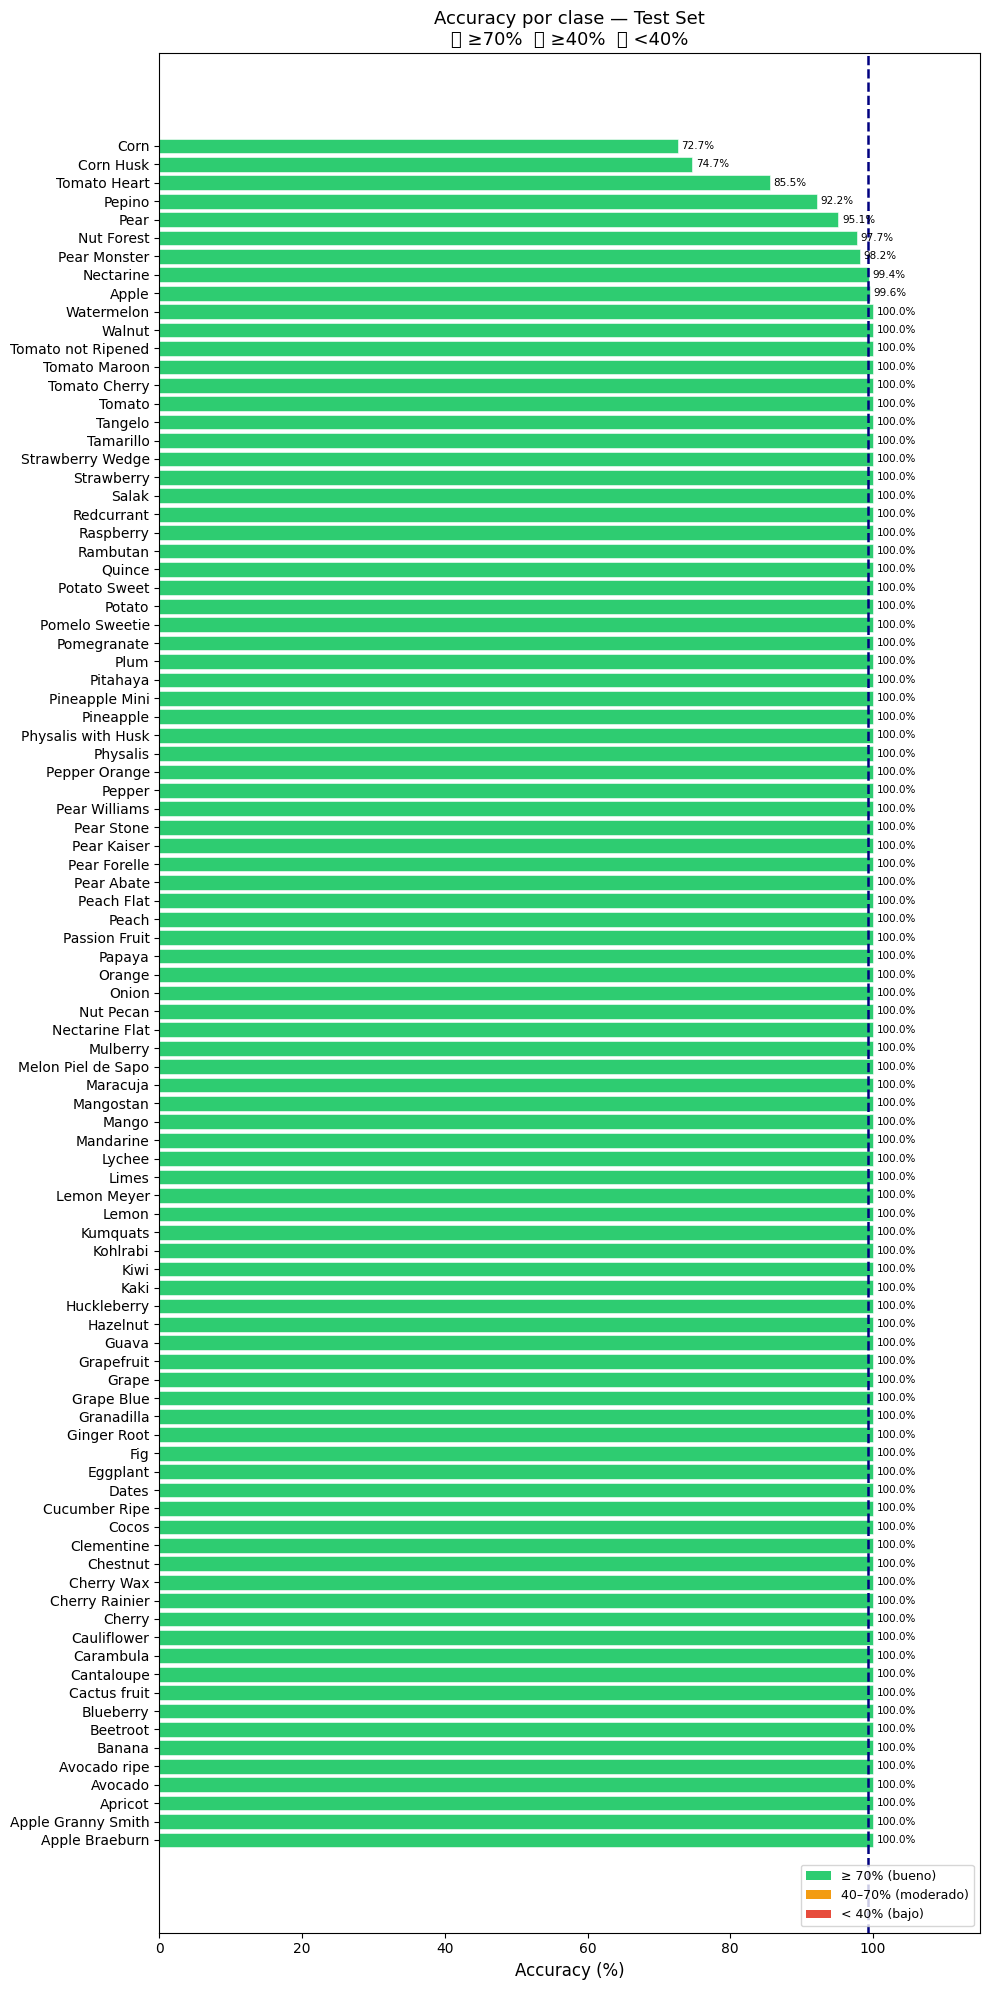

In [14]:
per_class = {}
for lbl in sorted(set(all_true.tolist())):
    mask = (all_true == lbl)
    if mask.sum() > 0:
        per_class[fused_classes[lbl]] = float((all_preds[mask] == lbl).mean())

sorted_acc = sorted(per_class.items(), key=lambda x: x[1], reverse=True)
names_all  = [x[0] for x in sorted_acc]
vals_all   = [x[1] * 100 for x in sorted_acc]
colors     = ['#2ecc71' if v >= 70 else '#f39c12' if v >= 40 else '#e74c3c' for v in vals_all]

fig, ax = plt.subplots(figsize=(10, 20))
ax.barh(names_all, vals_all, color=colors, edgecolor='white', linewidth=0.4)
ax.axvline(top1 * 100, color='navy', linestyle='--', linewidth=1.8,
           label=f'Media global: {top1*100:.1f}%')
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy por clase — Test Set\n🟢 ≥70%  🟠 ≥40%  🔴 <40%', fontsize=13)
ax.set_xlim(0, 115)
for i, v in enumerate(vals_all):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=7.5)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#2ecc71', label='≥ 70% (bueno)'),
    Patch(facecolor='#f39c12', label='40–70% (moderado)'),
    Patch(facecolor='#e74c3c', label='< 40% (bajo)'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('accuracy_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.2 Top-10 mejores y peores clases

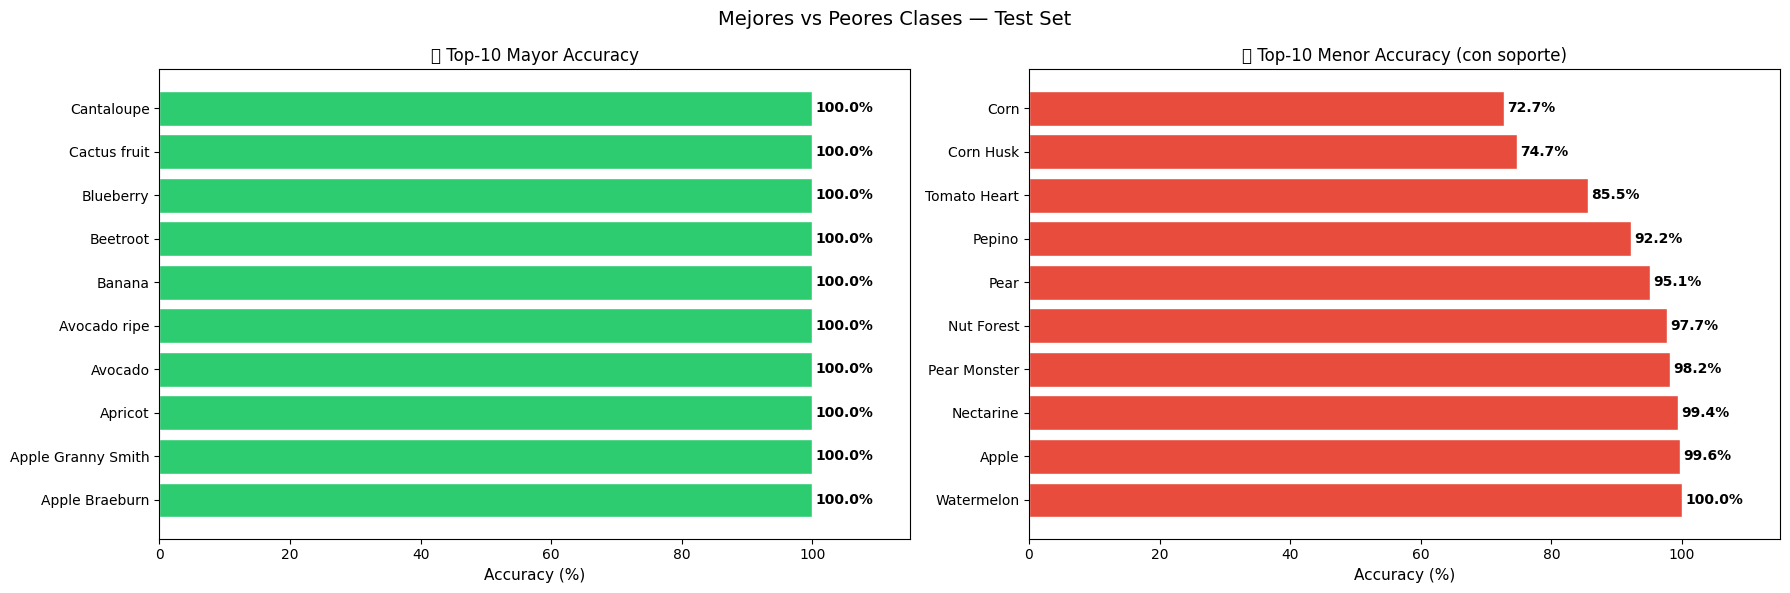

In [15]:
best10  = sorted_acc[:10]
worst10 = [x for x in sorted_acc if x[1] > 0][-10:]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, data, color, title in zip(
    axes,
    [best10, worst10],
    ['#2ecc71', '#e74c3c'],
    ['✅ Top-10 Mayor Accuracy', '❌ Top-10 Menor Accuracy (con soporte)']
):
    names, vals = zip(*data)
    vals_pct = [v * 100 for v in vals]
    ax.barh(names, vals_pct, color=color, edgecolor='white')
    ax.set_xlabel('Accuracy (%)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 115)
    for i, v in enumerate(vals_pct):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Mejores vs Peores Clases — Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('top_bottom_clases.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.3 Matriz de confusión normalizada

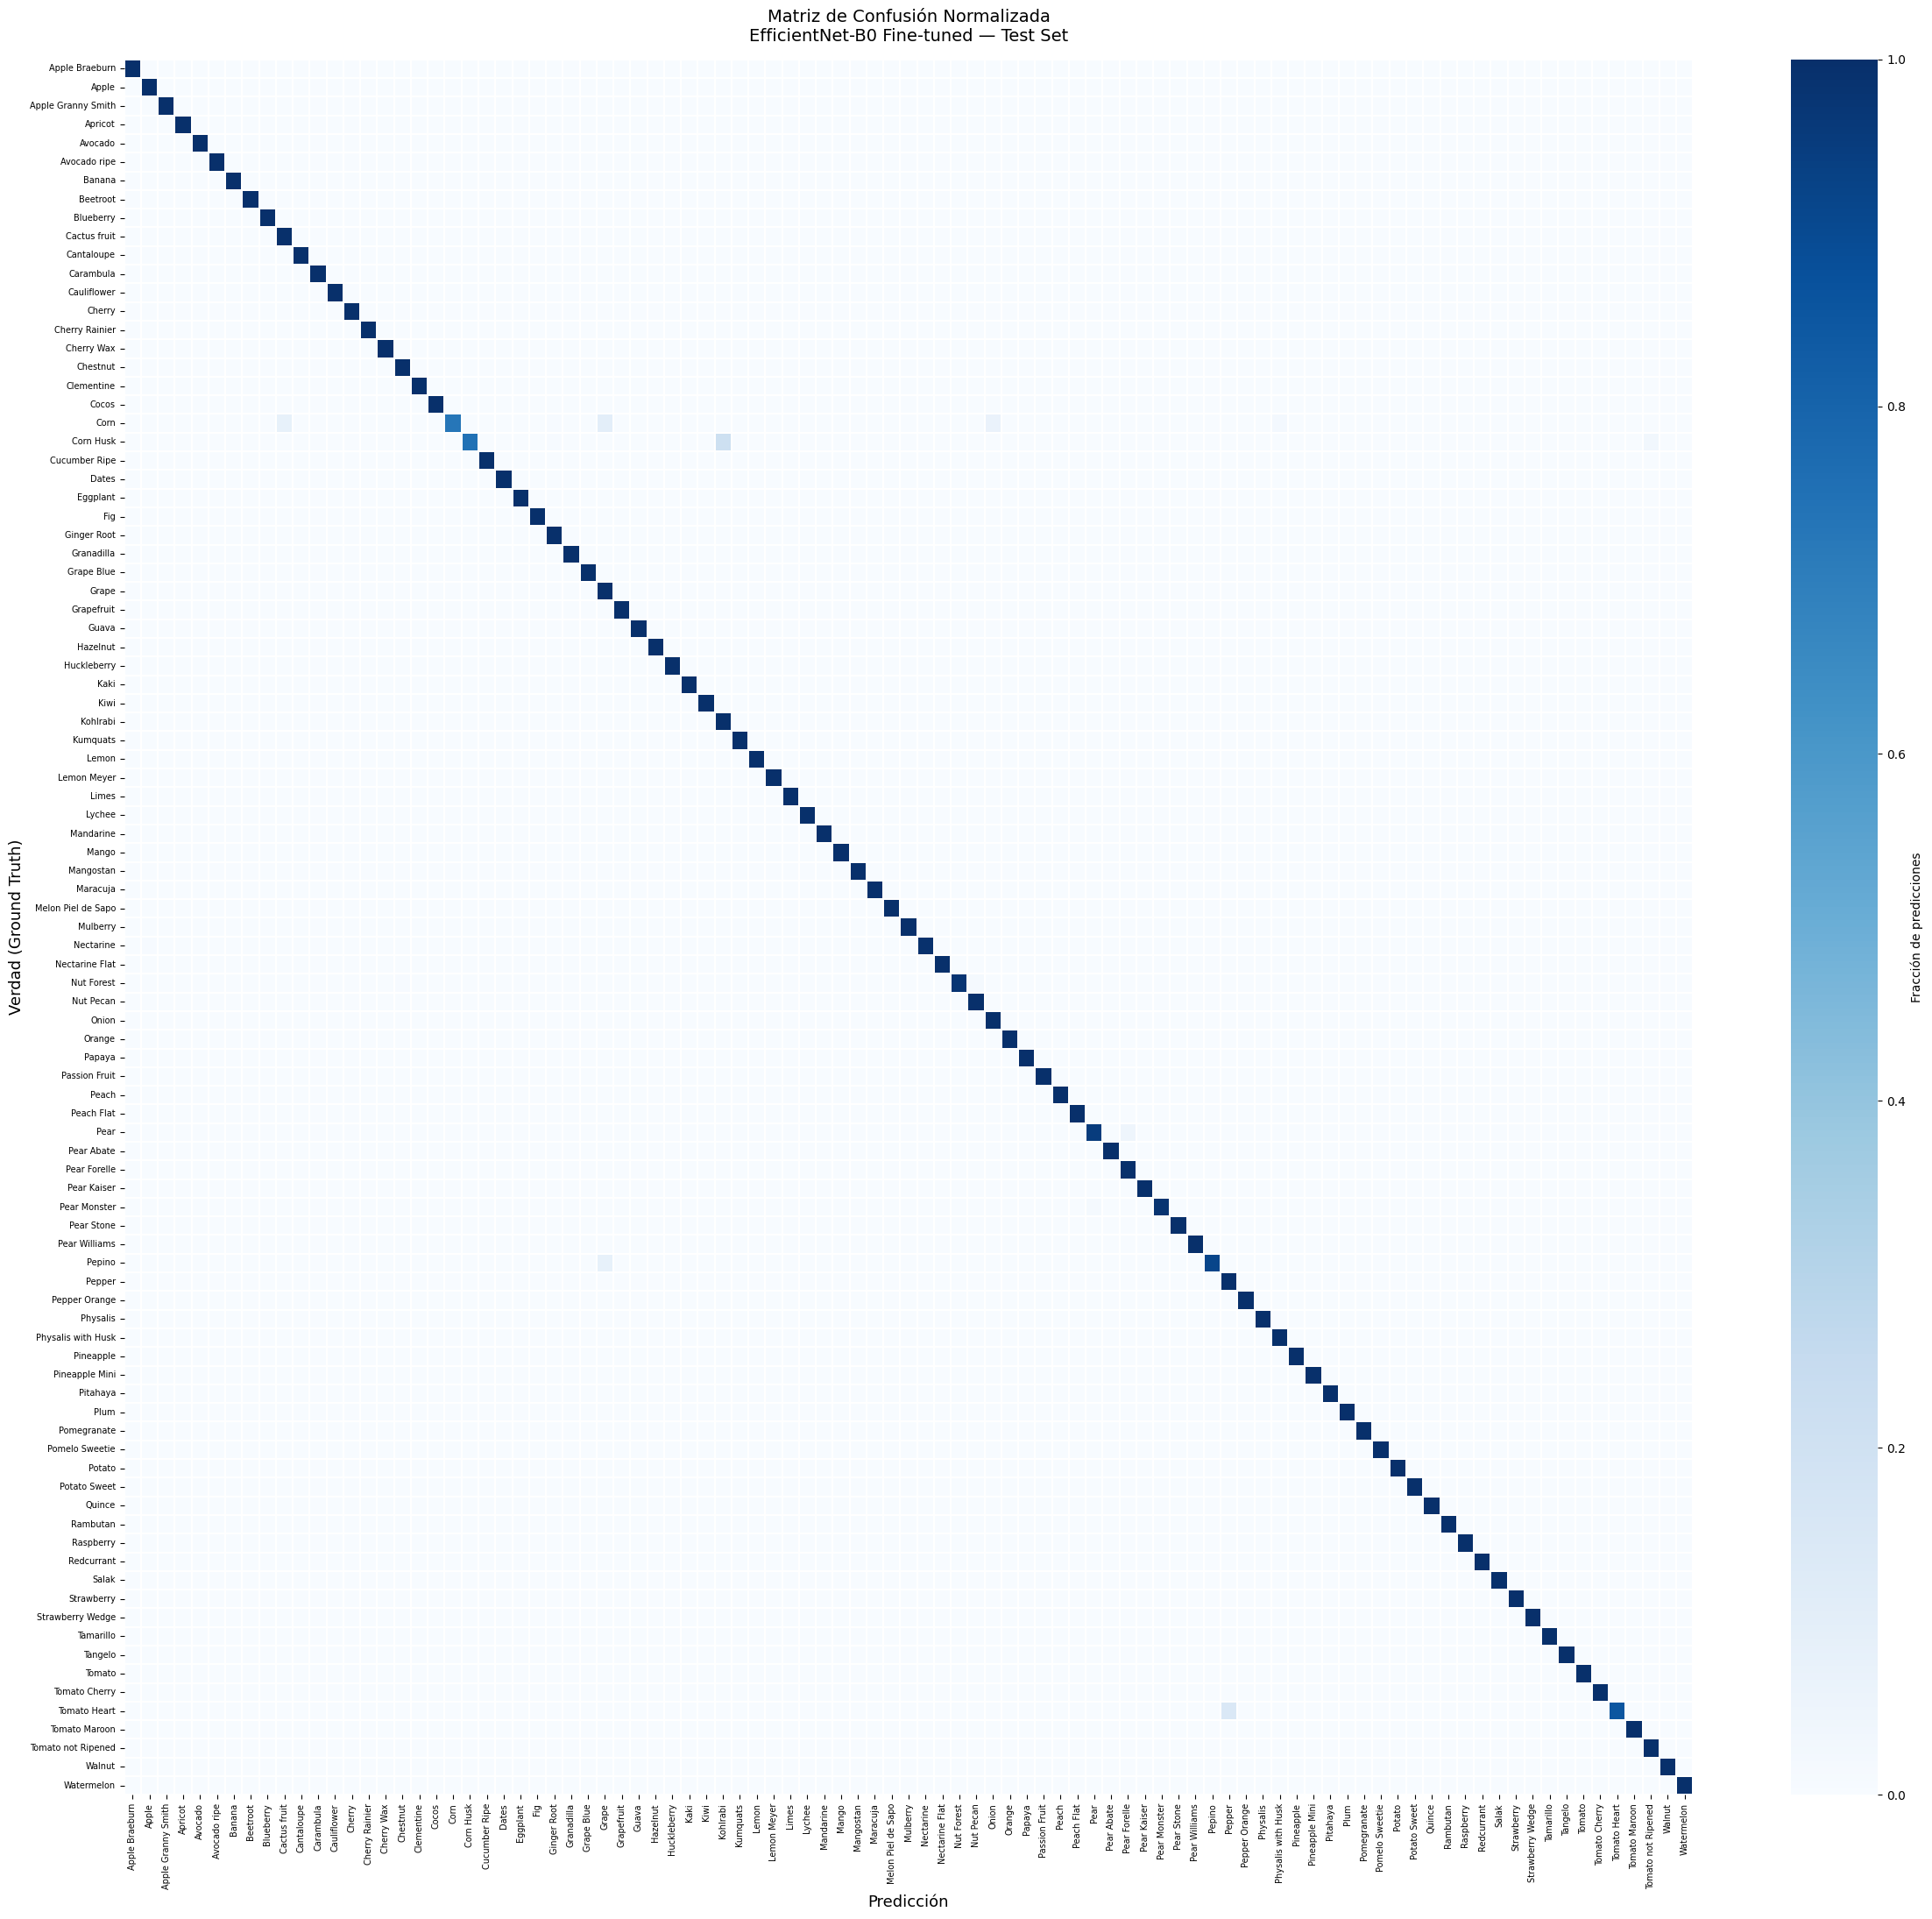

In [16]:
labels_sup = sorted(set(all_true.tolist()))
names_sup  = [fused_classes[i] for i in labels_sup]

cm      = confusion_matrix(all_true, all_preds, labels=labels_sup)
cm_norm = (cm.astype(float) / cm.sum(axis=1, keepdims=True))
cm_norm = np.nan_to_num(cm_norm)

fig, ax = plt.subplots(figsize=(24, 22))
sns.heatmap(cm_norm, xticklabels=names_sup, yticklabels=names_sup,
            cmap='Blues', vmin=0, vmax=1, linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Fracción de predicciones'})
ax.set_xlabel('Predicción', fontsize=13)
ax.set_ylabel('Verdad (Ground Truth)', fontsize=13)
ax.set_title('Matriz de Confusión Normalizada\nEfficientNet-B0 Fine-tuned — Test Set',
             fontsize=14, pad=15)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.4 Distribución de confianza

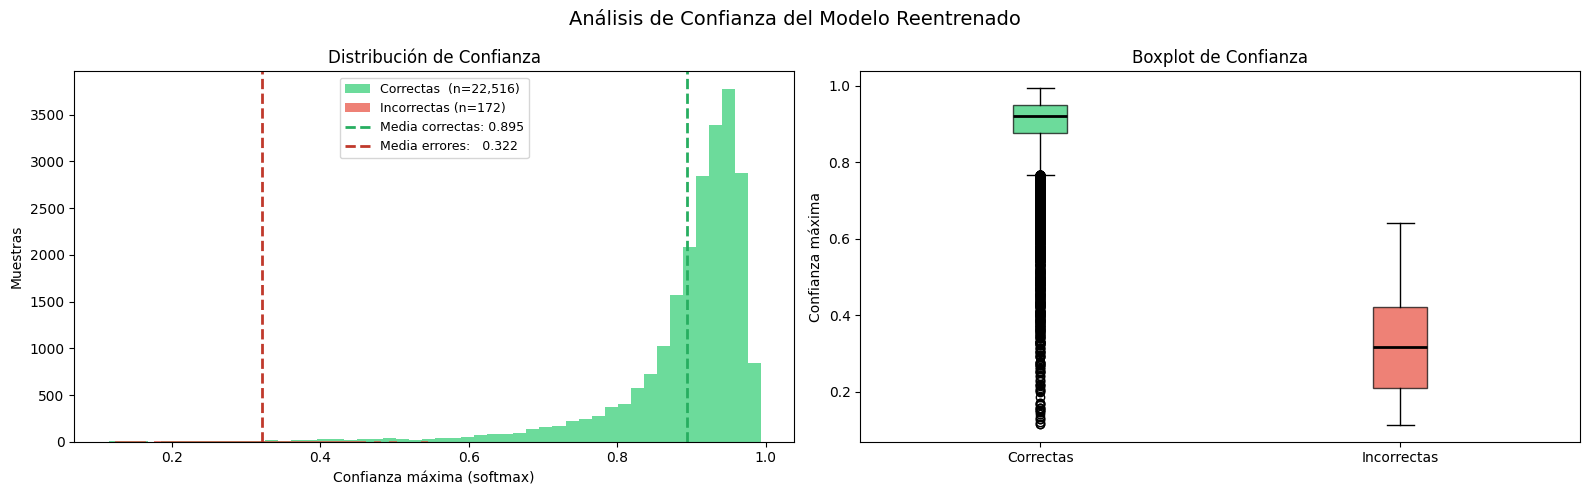

In [17]:
max_probs    = all_probs.max(axis=1)
correct_mask = (all_preds == all_true)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(max_probs[correct_mask],  bins=50, alpha=0.7, color='#2ecc71',
             label=f'Correctas  (n={correct_mask.sum():,})')
axes[0].hist(max_probs[~correct_mask], bins=50, alpha=0.7, color='#e74c3c',
             label=f'Incorrectas (n={(~correct_mask).sum():,})')
axes[0].axvline(conf_ok,  color='#27ae60', linestyle='--', lw=2,
                label=f'Media correctas: {conf_ok:.3f}')
axes[0].axvline(conf_err, color='#c0392b', linestyle='--', lw=2,
                label=f'Media errores:   {conf_err:.3f}')
axes[0].set_xlabel('Confianza máxima (softmax)')
axes[0].set_ylabel('Muestras')
axes[0].set_title('Distribución de Confianza')
axes[0].legend(fontsize=9)

bp = axes[1].boxplot([max_probs[correct_mask], max_probs[~correct_mask]],
                     labels=['Correctas', 'Incorrectas'], patch_artist=True)
bp['boxes'][0].set(facecolor='#2ecc71', alpha=0.7)
bp['boxes'][1].set(facecolor='#e74c3c', alpha=0.7)
for m in bp['medians']:
    m.set(color='black', linewidth=2)
axes[1].set_ylabel('Confianza máxima')
axes[1].set_title('Boxplot de Confianza')

plt.suptitle('Análisis de Confianza del Modelo Reentrenado', fontsize=14)
plt.tight_layout()
plt.savefig('confianza.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.5 Ejemplos visuales: aciertos y errores

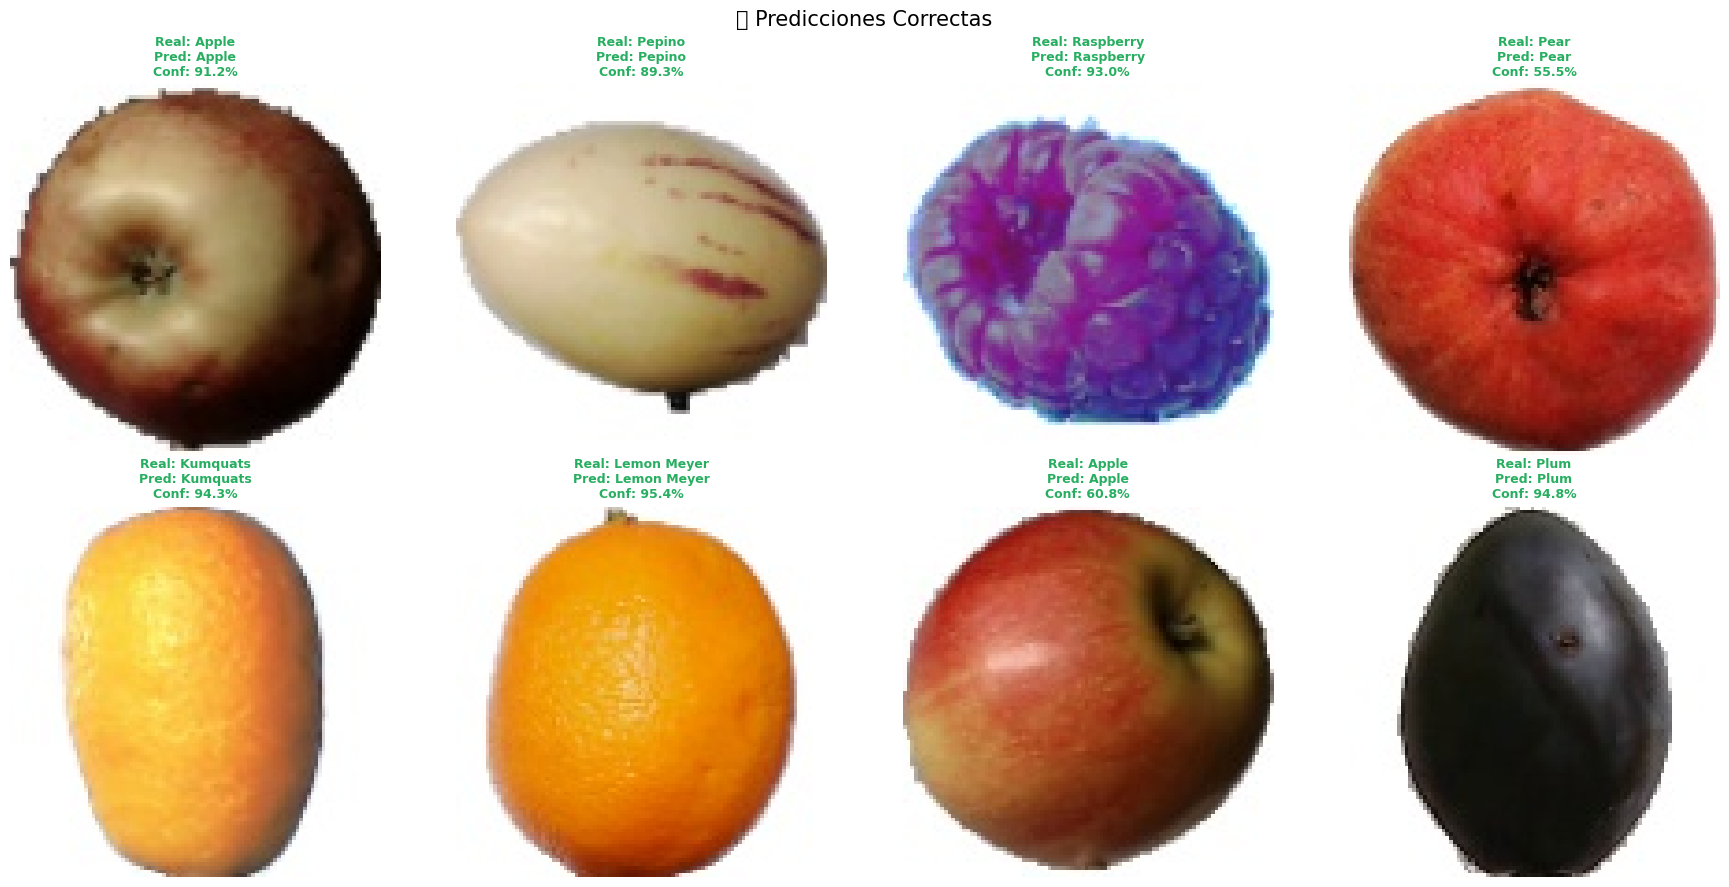

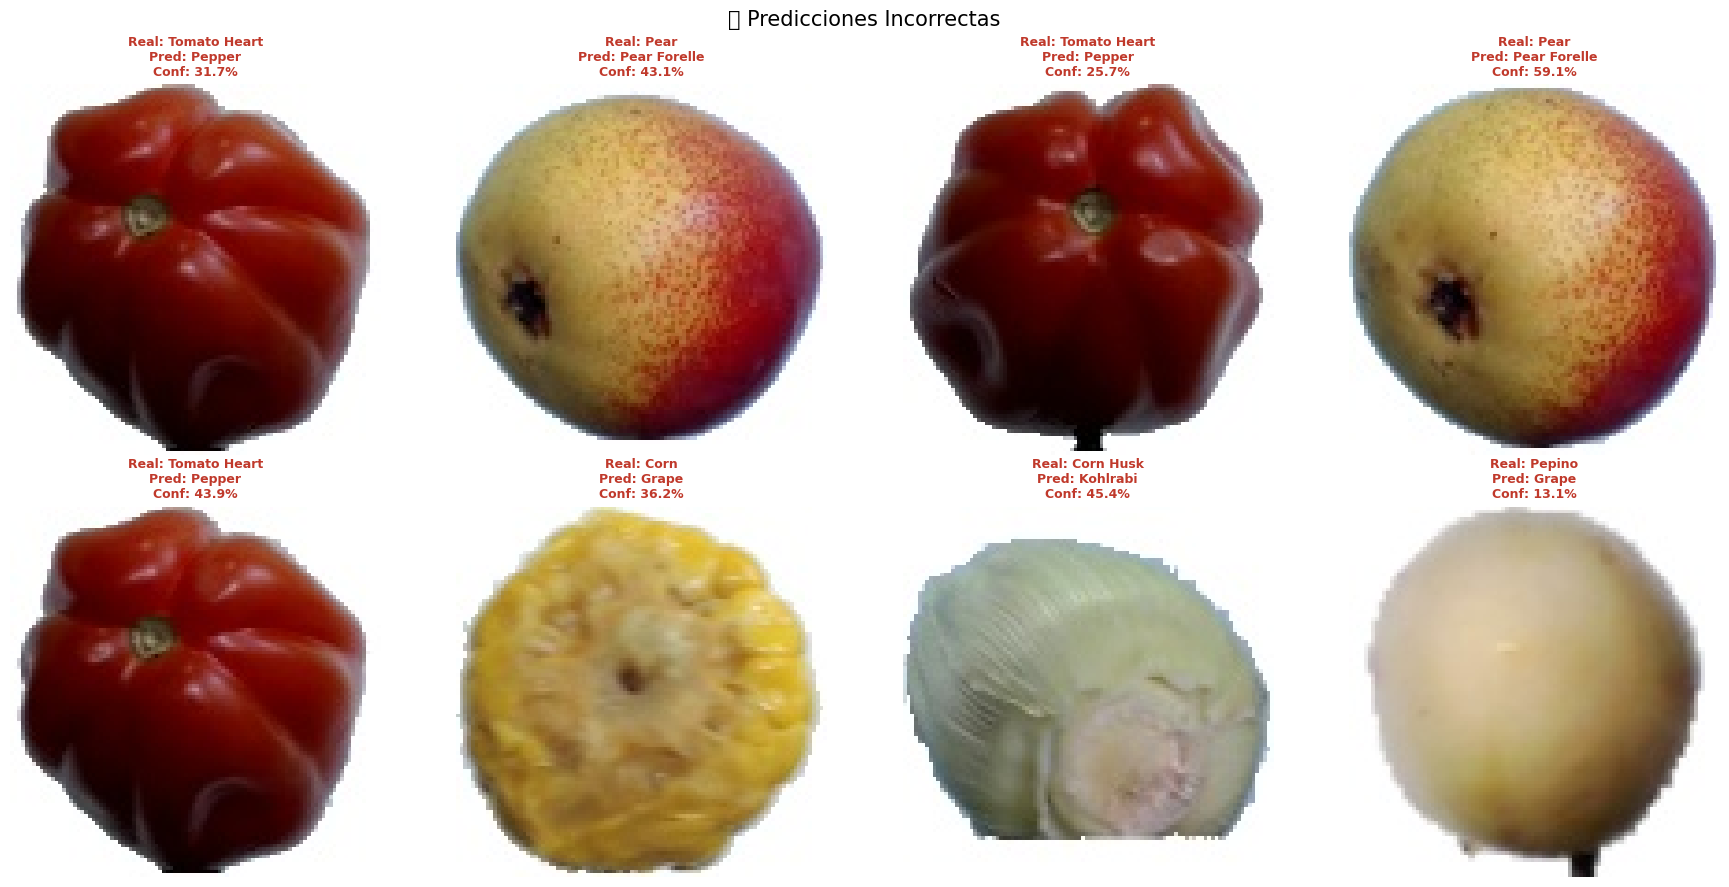

In [18]:
def show_samples(hf_dataset, label_map_inv, all_true, all_preds, all_probs,
                 fused_classes, correct=True, n=8, seed=42):
    rng  = np.random.default_rng(seed)
    mask = (all_preds == all_true) if correct else (all_preds != all_true)
    pool = np.where(mask)[0]
    idxs = rng.choice(pool, size=min(n, len(pool)), replace=False)

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle('✅ Predicciones Correctas' if correct else '❌ Predicciones Incorrectas',
                 fontsize=15)
    color = '#27ae60' if correct else '#c0392b'

    for ax, si in zip(axes.flatten(), idxs):
        ex       = hf_dataset[int(si)]
        img      = ex['image'].convert('RGB')
        true_lbl = fused_classes[all_true[si]]
        pred_lbl = fused_classes[all_preds[si]]
        conf     = all_probs[si].max()
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'Real: {true_lbl}\nPred: {pred_lbl}\nConf: {conf:.1%}',
                     fontsize=9, color=color, fontweight='bold')

    plt.tight_layout()
    fname = 'ejemplos_correctos.png' if correct else 'ejemplos_incorrectos.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()

show_samples(test_hf, orig_idx_to_fused_idx, all_true, all_preds,
             all_probs, fused_classes, correct=True)
show_samples(test_hf, orig_idx_to_fused_idx, all_true, all_preds,
             all_probs, fused_classes, correct=False)

## 15. Guardar modelo y configuración

In [19]:
# Guardar pesos del modelo
torch.save(model.state_dict(), '/content/efficientnet_b0_fruits360_finetuned.pth')

# Guardar configuración compatible con el modelo original
model_config = {
    'num_labels': NUM_CLASSES,
    'id2label'  : {str(i): c for i, c in enumerate(fused_classes)},
    'label2id'  : {c: str(i) for i, c in enumerate(fused_classes)},
    'architecture': 'efficientnet_b0',
    'img_size'    : IMG_SIZE,
    'top1_acc'    : round(top1, 4),
    'top5_acc'    : round(top5, 4),
}
with open('/content/config_finetuned.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print('Archivos guardados:')
print('  /content/efficientnet_b0_fruits360_finetuned.pth  ← pesos del modelo')
print('  /content/config_finetuned.json                    ← configuración')
print(f'\nTop-1 Accuracy final: {top1 * 100:.2f}%')
print(f'Top-5 Accuracy final: {top5 * 100:.2f}%')

Archivos guardados:
  /content/efficientnet_b0_fruits360_finetuned.pth  ← pesos del modelo
  /content/config_finetuned.json                    ← configuración

Top-1 Accuracy final: 99.24%
Top-5 Accuracy final: 99.93%
